In [36]:
import os 
print(os.getcwd())

c:\Users\gaaya\OneDrive\Desktop\Thesis\Final-Prosthetic-Control\src


In [37]:
path = r"C:\Users\gaaya\OneDrive\Desktop\Thesis\Final-Prosthetic-Control\data\raw"
print(os.listdir(path))

['co_contraction.csv', 'flex_extend_cycles.csv', 'hand_close.csv', 'hand_open.csv', 'object_transfer.csv', 'open_close_cycles.csv', 'pronation.csv', 'radial_deviation.csv', 'rest_baseline.csv', 'rotation_cycles.csv', 'supination.csv', 'ulnar_deviation.csv', 'wrist_extension.csv', 'wrist_flexion.csv', 'zipper_task.csv']


In [38]:
df = pd.read_csv(
    r"C:\Users\gaaya\OneDrive\Desktop\Thesis\Final-Prosthetic-Control\data\raw\hand_open.csv",
    skiprows=8,
    header=None,
    nrows = 20000  # only load the first 10k rows because of MemoryError 
)

print(df.shape)
df.head()

(20000, 108)


,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
0,0.000000,-0.020478,0,-0.8533325,0,0.1905518,0,-0.5618896,0,-20.7557259,...,,,,,,,,,,
1,0.000794,-0.023163,0.00675,-0.8500977,0.00675,0.1902466,0.00675,-0.5621948,0.00675,-19.8854961,...,,,,,,,,,,
2,0.001588,-0.020981,0.0135,-0.8408813,0.0135,0.1918945,0.0135,-0.5568237,0.0135,-18.8244267,...,,,,,,,,,,
3,0.002382,-0.020646,0.02025,-0.822937,0.02025,0.1988525,0.02025,-0.5466919,0.02025,-17.3664131,...,,,,,,,,,,
4,0.003177,-0.025849,0.027,-0.8120117,0.027,0.2078857,0.027,-0.5445557,0.027,-16.5496178,...,,,,,,,,,,


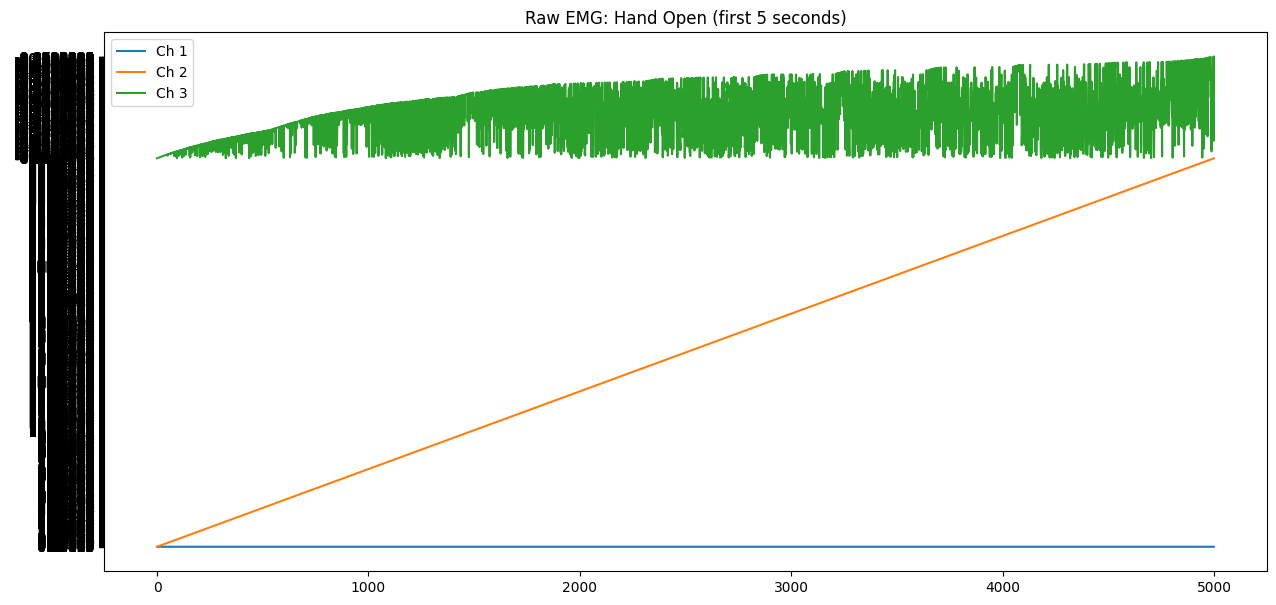

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 

# different emg electrodes (muscle activity)
plt.figure(figsize=(15,7))
plt.plot(df.iloc[:5000, 1], label="Ch 1") # this seems like the emg 1
plt.plot(df.iloc[:5000, 2], label="Ch 2") # time series (s)
plt.plot(df.iloc[:5000, 3], label="Ch 3") #acro or gyro signal 
plt.legend()
plt.title("Raw EMG: Hand Open (first 5 seconds)")
plt.show()

In [41]:
# Inspect first 20 columns to see the pattern
df.iloc[:5, :20]

# 0: EMG time, 1: EMG mV, 2: ACC time, 3: ACC X, 4: ACC time, 5: ACC Y, 6: ACC time, 7: ACC Z, 8: GYRO time, 9: GYRO X

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.000000,-0.020478,0,-0.8533325,0,0.1905518,0,-0.5618896,0,-20.7557259,0,1.3587786,0,-5.7022901,0.000000,0.000315,0.000000,-0.026184,0,0.2814331
1,0.000794,-0.023163,0.00675,-0.8500977,0.00675,0.1902466,0.00675,-0.5621948,0.00675,-19.8854961,0.00675,-3.2900763,0.00675,-5.5725193,0.000021,0.000297,0.000794,-0.026352,0.00675,0.2683716
2,0.001588,-0.020981,0.0135,-0.8408813,0.0135,0.1918945,0.0135,-0.5568237,0.0135,-18.8244267,0.0135,-9.0839691,0.0135,-5.3664122,0.000042,0.000403,0.001588,-0.025681,0.0135,0.2717896
3,0.002382,-0.020646,0.02025,-0.822937,0.02025,0.1988525,0.02025,-0.5466919,0.02025,-17.3664131,0.02025,-13.9312973,0.02025,-5.3664122,0.000063,0.000314,0.002382,-0.018296,0.02025,0.2786865
4,0.003177,-0.025849,0.027,-0.8120117,0.027,0.2078857,0.027,-0.5445557,0.027,-16.5496178,0.027,-15.8625956,0.027,-5.2366414,0.000083,0.000244,0.003177,-0.009232,0.027,0.2808228


In [ ]:
emg_cols = list(range(1, df.shape[1], 18)) # every 18th coloumn staring from coloumn 1, one sensor block
emg = df.iloc[:, emg_cols].values  

#(samples, channels)

print(emg.shape)

(20000, 6)


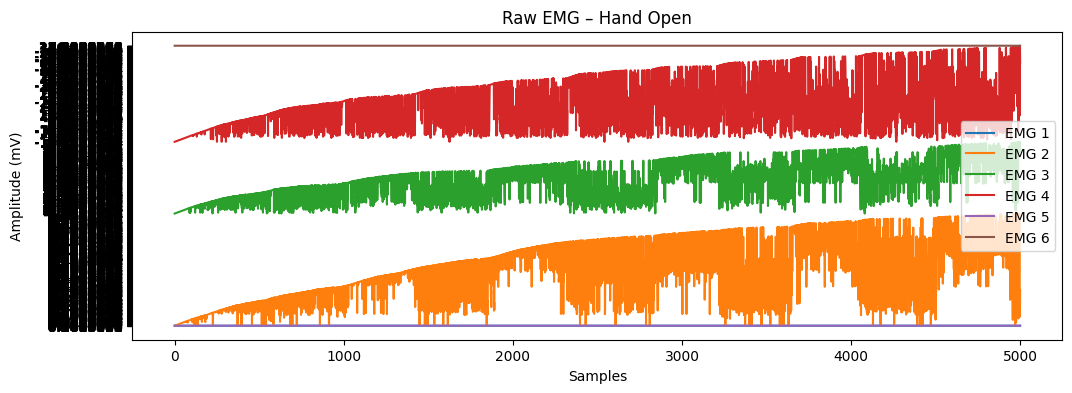

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
for i in range(emg.shape[1]):
    plt.plot(emg[:5000, i], label=f"EMG {i+1}")

plt.legend()
plt.title("Raw EMG – Hand Open")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.show()

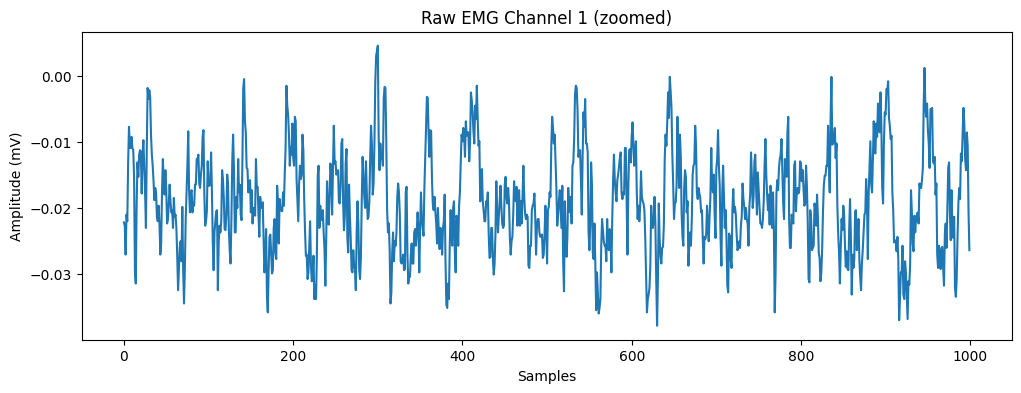

In [44]:
# signal channel zoomed in 

ch = 0  # index
plt.figure(figsize=(12,4))
plt.plot(emg[2000:3000, ch])
plt.title(f"Raw EMG Channel {ch+1} (zoomed)")
plt.xlabel("Samples")
plt.ylabel("Amplitude (mV)")
plt.show()

In [5]:
import pandas as pd
import numpy as np


df = pd.read_csv(
    r"C:\Users\gaaya\OneDrive\Desktop\Thesis\Final-Prosthetic-Control\data\raw\hand_open.csv",
    skiprows=8,
    header=None,
    nrows=10000   # small chunk for safety
)

print(df.shape)

emg_cols = list(range(1, df.shape[1], 18)) 
# I only want every 18th column starting at index 1

emg = (
    df.iloc[:, emg_cols]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float64)
)

# drop rows that are completely NaN
emg = emg[~np.isnan(emg).all(axis=1)]

signal = emg[:, 0]

print("Signal length:", len(signal))   # total no. of samples 
print("Min:", np.nanmin(signal))       # minimum value excluding NaNs
print("Max:", np.nanmax(signal))       # maximum value (0 - 5 is raw ADC volts)
print("Std:", np.nanstd(signal))       # standard deviation 

(10000, 108)
Signal length: 10000
Min: -0.2552987
Max: 0.2049439
Std: 0.025024720315321415


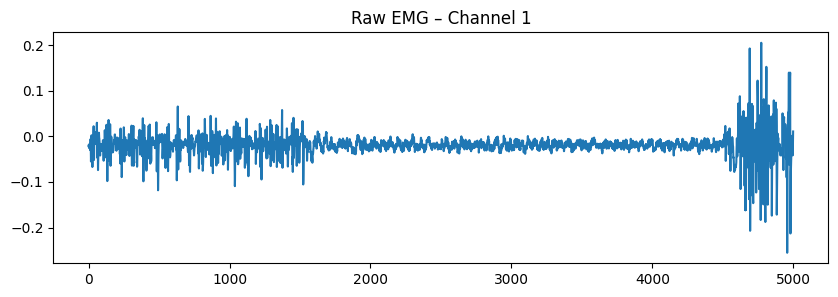

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))
plt.plot(signal[:5000])
plt.title("Raw EMG – Channel 1")
plt.show()
